## *Equipe*
## Victor 
## Rodrigo 
## Ex.integrante: Kamila

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
path= 'C:/Users/rodrigo/Desktop/Machine Learning Aplicada/Nova_atividade/folhasamostras/classe1/'

In [3]:
num_classes = 2

In [4]:
modelo_base = ResNet50(weights='imagenet', include_top = False, input_shape = (224, 224, 3))

In [5]:
modelo_novo = modelo_base.output
modelo_novo = GlobalAveragePooling2D()(modelo_novo)
modelo_novo = Dense(1024, activation = 'relu')(modelo_novo)
predicoes = Dense(num_classes, activation = 'softmax')(modelo_novo)

In [6]:
modelo = Model(inputs = modelo_base.input, outputs = predicoes)

In [7]:
for layer in modelo_base.layers:
    layer.trainable = False

In [8]:
modelo.compile(optimizer=Adam(learning_rate=0.001),
               loss = 'categorical_crossentropy',
               metrics=['accuracy'])

## Treino

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

In [10]:
validation_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

In [11]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'Train'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 61 images belonging to 2 classes.


## Validação

In [12]:
validation_generator = validation_datagen.flow_from_directory(
    os.path.join(path, 'Test'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 22 images belonging to 2 classes.


In [14]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img

In [15]:
class_labels = list(validation_generator.class_indices.keys())
def classifica_imagem(imagem):
    img = load_img(imagem, target_size = (224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis = 0)
    img_ = preprocess_input(img_)
    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis = 1)[0]
    rotulo_predito = class_labels[classe_predita]
    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4}")
    

In [17]:
modelo.save('resnet_10_epoch_folhasamostras.keras')

In [18]:
imagem = path + 'b24.JPEG'

In [19]:
path

'C:/Users/rodrigo/Desktop/Machine Learning Aplicada/Nova_atividade/folhasamostras/classe1/'

1/1 [==============================] - 1s 718ms/step
Classe predita: Defeituosa - 0.9993


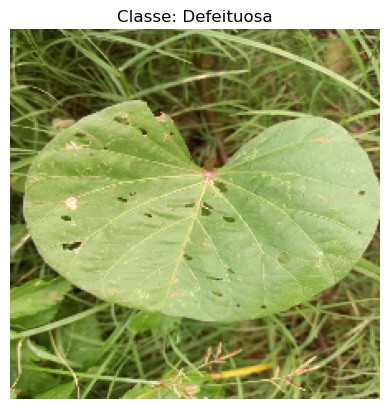

In [20]:
class_labels = list(validation_generator.class_indices.keys())

def classifica_imagem(imagem):
    
    img = load_img(imagem, target_size=(224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis=0)
    img_ = preprocess_input(img_)

    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis=1)[0]
    rotulo_predito = class_labels[classe_predita]

    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4f}")

    plt.imshow(img)
    plt.title(f"Classe: {rotulo_predito}")
    plt.axis("off")
    plt.show()

classifica_imagem(imagem)

## Extração de características usando o modelo ResNet50

In [21]:
train_features = modelo_base.predict(train_generator)
train_labels = train_generator.classes

7/7 [==============================] - 5s 542ms/step


In [22]:
test_features = modelo_base.predict(validation_generator)
test_labels = validation_generator.classes

3/3 [==============================] - 1s 294ms/step


## Utilize o PCA e teste 3 classificadores tradicionais para indicar o melhor resultado: SVM, Random Forest e Logistic Regression.

In [23]:
n_components = min(50, train_features.shape[0])  # 50 ou o número de amostras (48)
pca = PCA(n_components=n_components)
train_features_pca = pca.fit_transform(train_features.reshape(train_features.shape[0], -1))
test_features_pca = pca.transform(test_features.reshape(test_features.shape[0], -1))

In [24]:
classifiers = {
    "SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(train_features_pca, train_labels)
    preds = clf.predict(test_features_pca)
    results[name] = {
        "Classification Report": classification_report(test_labels, preds, target_names=class_labels),
        "Confusion Matrix": confusion_matrix(test_labels, preds)
    }

## Indique o que obteve o melhor resultado e comprove com a comparação dos métodos (matriz de confusão e relatório de classificação).


SVM Results:
              precision    recall  f1-score   support

  Defeituosa       0.52      1.00      0.69        11
 NDefeituosa       1.00      0.09      0.17        11

    accuracy                           0.55        22
   macro avg       0.76      0.55      0.43        22
weighted avg       0.76      0.55      0.43        22



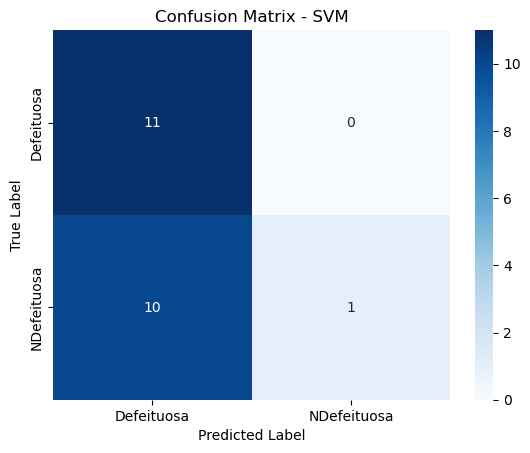


Random Forest Results:
              precision    recall  f1-score   support

  Defeituosa       0.53      0.73      0.62        11
 NDefeituosa       0.57      0.36      0.44        11

    accuracy                           0.55        22
   macro avg       0.55      0.55      0.53        22
weighted avg       0.55      0.55      0.53        22



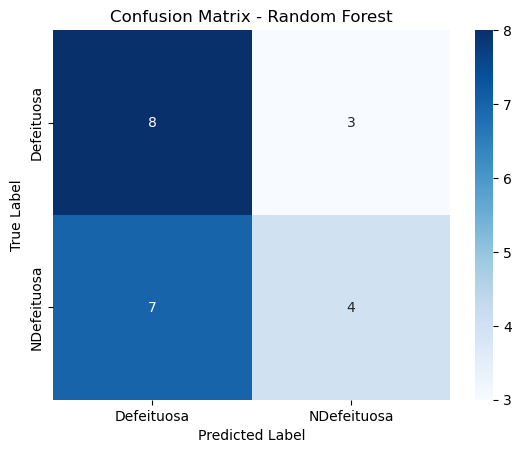


Logistic Regression Results:
              precision    recall  f1-score   support

  Defeituosa       0.52      1.00      0.69        11
 NDefeituosa       1.00      0.09      0.17        11

    accuracy                           0.55        22
   macro avg       0.76      0.55      0.43        22
weighted avg       0.76      0.55      0.43        22



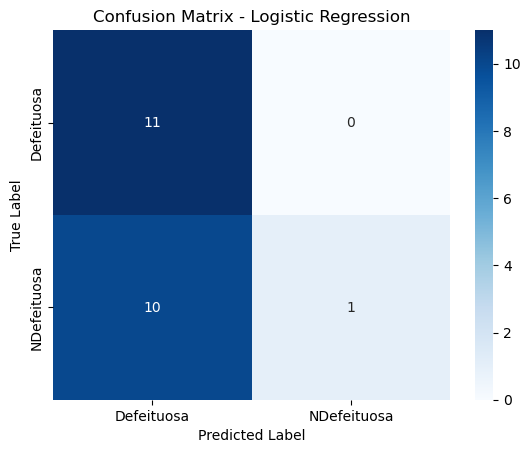

In [25]:
for name, result in results.items():
    print(f"\n{name} Results:")
    print(result["Classification Report"])
    sns.heatmap(result["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()